# Error Normalized Distance Study
In this notebook we study the error normalized distance distribution, and its correlation with other parameters, computed from our own crossmatch algorithm using only those stars present in the Marrese crossmatch

We make use of the Gaia DR3 and Hipparcos catalogues
Further inclusions:
 -  Proper Motion Anomaly table by Kervella+21

In [1]:
# Library Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import copy

# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')
# Laptop
sys.path.append('/home/rens/projects/mp_dir/masterproject/src/')

from plotting_functions import set_styles
from data_queries import query_extra_data
from astrometry_equations import rayleigh, compute_error_normalized_distance
from hipp_preprocess import extract_cov

In [2]:
# Define Paths
fpath = '../../../figures/'
rpath = '../../results/'
dpath = '../../../data/'

set_styles()

# Data
We have to extract our Gaia astrometry from locally stored catalogues, because it is backpropagated to J1991.25. However, all other parameters we just query from the Archive for flexibility, and due to storage limitations

In [5]:
# Potential Parameters throughout this notebook
gaia_cat_ext = '_Final'
xm_radius = '10as'
xm_selection = 'nearest'

In [7]:
# Hipparcos - Gaia indexes of the cross match
crossmatch_idxs = np.load(f'{rpath}marrese_crossmatch_{xm_radius}_best_neighbour_{xm_selection}.npy')
gaia_cat = fits.open(f'{dpath}GaiaBaseCat{gaia_cat_ext}.fits')[1].data
hipp_cat = fits.open(f'{dpath}Hipparcos_mix.fits')[1].data

# Make a table matching the XM order containing all propagated Gaia astrometry
pos_gaia_table_full = copy.deepcopy(gaia_cat)
pos_gaia_table_full = pos_gaia_table_full[crossmatch_idxs[:,2]]
_, pos_hipp_table_full = query_extra_data(crossmatch_idxs, ['hip', 'ra', 'dec', 'e_ra_rad', 'e_de_rad'], cat='hipp')


# Indexing this table is slightly more work because we do not have the table idxs stored
pos_hipp_table_full = copy.deepcopy(hipp_cat)

hip_indexes = np.zeros(crossmatch_idxs.shape[0], dtype=np.int64)
for i in range(crossmatch_idxs.shape[0]):
    hip_indexes[i] = int(np.where(hipp_cat['hip'] == crossmatch_idxs[i][0])[0][0])
    #print(hip_indexes)
pos_hipp_table_full = pos_hipp_table_full[hip_indexes]

print(f'Imported {crossmatch_idxs.shape[0]} potential Gaia - Hipparcos matches')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
Imported 99524 potential Gaia - Hipparcos matches


In [19]:
# Auxiliary data importing from the archive
#extra_gaia_data_params = ['ipd_frac_multi_peak', 'ipd_frac_odd_win', 'ipd_gof_harmonic_amplitude']
#extra_gaia_data_params = ['phot_g_mean_mag', 'bp_rp', 'pseudocolour', 'radial_velocity_error', 'ruwe', 'matched_transits', 'visibility_periods_used', 'duplicated_source', 'non_single_star']
extra_gaia_data_params = ['phot_g_mean_mag', 'pmra', 'bp_rp', 'parallax', 'parallax_error', 'pmdec', 'ruwe', 'ipd_frac_multi_peak',  'ipd_gof_harmonic_amplitude']
extra_hipp_data_params = ['hp_mag', 'b_v']

_, extra_gdata = query_extra_data(crossmatch_idxs, extra_gaia_data_params)
_, extra_hdata = query_extra_data(crossmatch_idxs, extra_hipp_data_params, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


In [ ]:
# Importing of additional databases
kervella_tab = fits.open(dpath+'marrese_1as_xm_base_kervella_pma-result.fits')

print(f"XM and Kervella Tables in same order: {np.array_equal(np.array(kervella_tab[1].data['hip'], dtype=int), pos_hipp_table_full['hip'])}")

pma_snr = np.array(kervella_tab[1].data['snrpmah2eg3b'])
bin_flag = np.array(kervella_tab[1].data['binh2eg3b'])

# Compare Brandt $\chi^2$ to Kervella PMa SNR
Only run separately!

In [42]:
# First match kervella on brandt
kervella_tab = fits.open(dpath+'kervela_pma.fits')
brandt_tab = fits.open(dpath+'HGCA_vEDR3.fits')
print(f'Number of objects in Brandt+21  : {brandt_tab[1].data.shape[0]}\n'
      f'Number of objects in Kervella+21: {kervella_tab[1].data.shape[0]}')

match_table = np.zeros((brandt_tab[1].data.shape[0], 2), dtype=np.int64)
num_matches = 0
for i in range(brandt_tab[1].data.shape[0]):
    match = np.where(brandt_tab[1].data['hip_id'][i] == kervella_tab[1].data['hip'])[0]

    if len(match) > 0:
        match_table[num_matches] = np.array([int(i), int(match[0])])
        num_matches += 1
match_table = match_table[:num_matches]


Number of objects in Brandt+21  : 115346
Number of objects in Kervella+21: 116017


In [43]:
kervella_tab = kervella_tab[1].data[match_table[:, 1]]
brandt_tab = brandt_tab[1].data[match_table[:, 0]]

In [65]:
print(kervella_tab['SNRPMaH2EG3b'][kervella_tab['SNRPMaH2EG3b'] > 0])

[0.]


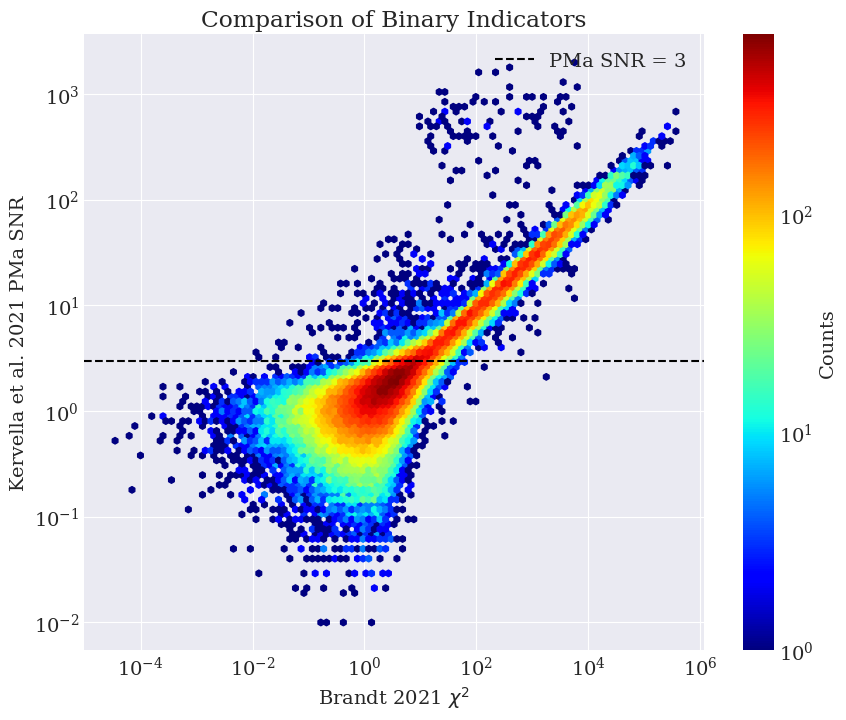

In [68]:

fig, ax = plt.subplots(1, 1, figsize=(10,8))
distribution = ax.hexbin(brandt_tab['chisq'][kervella_tab['SNRPMaH2EG3b'] > 0], kervella_tab['SNRPMaH2EG3b'][kervella_tab['SNRPMaH2EG3b'] > 0], mincnt=1, cmap='jet',
                         xscale='log', yscale='log', bins='log')
cb = plt.colorbar(distribution)
ax.axhline(y=3, c='black', ls='--', label='PMa SNR = 3')

#ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_xlabel(r'Brandt 2021 $\chi^2$')
ax.set_ylabel('Kervella et al. 2021 PMa SNR')
ax.set_title('Comparison of Binary Indicators')
cb.set_label('Counts')

plt.legend()
plt.savefig(fpath+'pmasnr_vs_chisq.png', bbox_inches='tight')
plt.show()

# Analysis

## Error Normalized Distance

In [ ]:
hip_mixed = True
if not hip_mixed:# Get the correlation factors from Hipparcos-2 ! ONLY FOR HIP2
    udata_hip2 = ['ntr', 'f2', 'e_ra_rad', 'e_de_rad', 'e_plx', 'e_pm_ra', 'e_pm_de']
    for i in range(1, 16):
        udata_hip2.append(f'u{i}')
    _, hipp_udata = query_extra_data(crossmatch_idxs, udata_hip2, cat='hipp')
    hip2_columns = []
    for i, col in enumerate(hipp_udata.T):
        hip2_columns.append(fits.Column(name=udata_hip2[i], array=col, format='F'))
    cols = fits.ColDefs(hip2_columns)
    hdu = fits.BinTableHDU.from_columns(cols)
    covar_hip2 = extract_cov(hdu.data)
    hipp_corr_radec = covar_hip2[:,0,1]

In [9]:
brandt_factor = 1./1.36
# Compute the complete error normalized distances array
pos_hipp = np.array([pos_hipp_table_full['ra'], pos_hipp_table_full['dec']]).T*3.6e6
pos_gaia = np.array([pos_gaia_table_full['ra_prop'], pos_gaia_table_full['dec_prop']]).T*3.6e6
unc_hipp = np.array([pos_hipp_table_full['e_ra_rad']**2, pos_hipp_table_full['e_de_rad']**2, pos_hipp_table_full['ra_dec_corr']]).T#pos_hipp_table_full['ra_dec_corr']]).T
unc_gaia = np.array([brandt_factor * pos_gaia_table_full['e_ra_prop']**2, brandt_factor * pos_gaia_table_full['e_de_prop']**2, pos_gaia_table_full['ra_dec_prop']]).T

error_norm_distances = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='full')

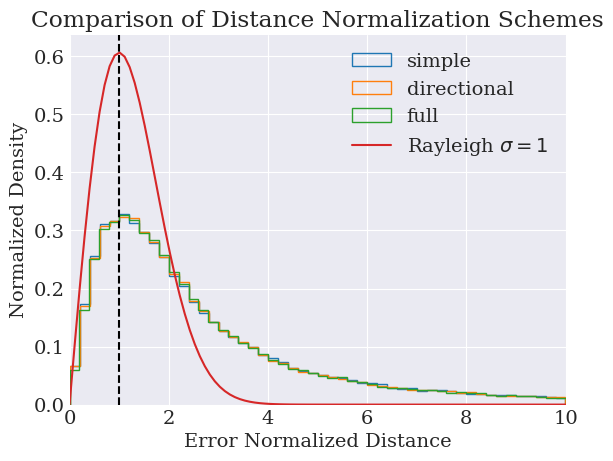

In [11]:
set_styles()
# Investigate the effect of different normalization methods
for method in ['simple', 'directional', 'full']:#, 'none']:
    error_norm_distances = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method=method)
    plt.hist(error_norm_distances[error_norm_distances < 10], bins=50, density=True, label=method, histtype='step')

x = np.linspace(0, 10, 100)
plt.plot(x, rayleigh(x, 1), label=r'Rayleigh $\sigma = 1$')
plt.axvline(x=1, c='black', ls='--')
plt.legend()
plt.xlim(0, 10)
plt.xlabel('Error Normalized Distance')
plt.ylabel('Normalized Density')
plt.title('Comparison of Distance Normalization Schemes')
#plt.savefig(fpath+'D_distribution_Marrese.png', bbox_inches='tight')
plt.show()

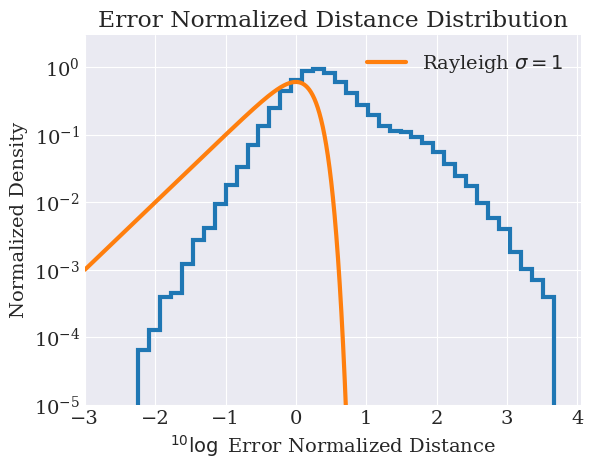

In [70]:
# Investigate the effect of different normalization methods in log space
for method in ['full']:#, 'none']:
    error_norm_distances = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method=method)
    plt.hist(np.log10(error_norm_distances), log=True, bins=50, density=True, histtype='step', lw=3)

x = np.logspace(-3, 1, 500)
plt.plot(np.log10(x), rayleigh(x, 1), label=r'Rayleigh $\sigma = 1$', lw=3)
#plt.axvline(x=0, c='black', ls='--', lw=4)
drop = 0.2
#plt.scatter(drop, rayleigh(10**drop, 1), c='black', marker='x', zorder=5, lw=3, s=100, label=r'Dropoff')
plt.legend()

plt.xlabel('$^{10}\log$ Error Normalized Distance')
plt.ylabel('Normalized Density')
plt.title('Error Normalized Distance Distribution')
plt.ylim(1e-5, 3)
plt.xlim(-3, )
plt.savefig(fpath+'logD_distribution_Marrese.png', bbox_inches='tight')
plt.show()

In [ ]:
# Plot single crossmatch with error ellipses
center_on_gaia = False
coordinates = 'cartesian'
deg_to_mas = 3600*1e3
i = np.random.choice(crossmatch_idxs.shape[0])
###

# RA, Dec are given in degrees. Convert both to mas to conform with the uncertainties
pos_hipp = np.array(pos_hipp_table_full[i][:2])*deg_to_mas
pos_gaia = np.array([pos_gaia_table_full[i]['ra_prop'], pos_gaia_table_full[i]['dec_prop']])*deg_to_mas

if center_on_gaia:
    # Shift potions such that the Gaia object is at (0, 0)
    pos_hipp -= pos_gaia
    pos_gaia -= pos_gaia
if coordinates == 'cartesian':
    # Then we have to make sure the alpha-uncertainties are scaled back to normal
    hipp_dec_rad, gaia_dec_rad = np.radians(pos_hipp[1]/3.6e6), np.radians(pos_gaia[1]/3.6e6) # 3600 * 1e3 = 3.6e6
    hipp_ra_corr, gaia_ra_corr = np.cos(hipp_dec_rad), np.cos(gaia_dec_rad)

unc_hipp = np.array([pos_hipp_table_full[i][2]**2, pos_hipp_table_full[i][3]**2, 0])
unc_gaia = np.array([(pos_gaia_table_full[i]['e_ra_prop']/hipp_ra_corr)**2, (pos_gaia_table_full[i]['e_de_prop']/gaia_ra_corr)**2, pos_gaia_table_full[i]['ra_dec_prop']])

# Distance measure using all four different methods
distance_mas = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='none', coordinates=coordinates)
D_simple = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='simple', coordinates=coordinates)
D_directional = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='directional', coordinates=coordinates)
D_full = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='full', coordinates=coordinates)

# Draw error ellipses individually using agapylib
ellipse_kwargs = {
    'fc': None,
    'fill': False
}
ellipse_hipp = error_ellipses(pos_hipp, unc_hipp, 1, **ellipse_kwargs, ec='C0')
ellipse_gaia = error_ellipses(pos_gaia, unc_gaia, 1, **ellipse_kwargs, ec='C1')
ellipse_combined = error_ellipses(pos_gaia, unc_gaia+unc_hipp, 1, **ellipse_kwargs, ec='red', label=rf'Combined Uncertainty [1, {D_simple:.2f}, {D_directional:.2f}, {D_full:.2f}]$\sigma$')
ellipse_combined_D = error_ellipses(pos_gaia, unc_gaia+unc_hipp, [D_simple, D_directional, D_full], **ellipse_kwargs, ec='red', ls='--')#$, label=rf'Combined Uncertainty {D_full:.2f}$\sigma$')

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

ax.scatter(pos_hipp[0], pos_hipp[1], c='C0', label=f'Hip {crossmatch_idxs[i][0]}')
ax.add_patch(ellipse_hipp[0])

ax.scatter(pos_gaia[0], pos_gaia[1], c='C1', label=f'Gaia {crossmatch_idxs[i][1]}')
ax.add_patch(ellipse_gaia[0])

ax.add_patch(ellipse_combined[0])
for i in range(len(ellipse_combined_D)):
    ax.add_patch(ellipse_combined_D[i])


ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=f'Distance: {distance_mas:.2f} mas')
ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=fr'D_simple {D_simple:.2f} $\sigma$')
ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=fr'D_directional: {D_directional:.2f} $\sigma$')
ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=fr'D_full: {D_full:.2f} $\sigma$')

if center_on_gaia:
    ax.set_xlabel(r'$\Delta$ RA [mas]')
    ax.set_ylabel(r'$\Delta$ Dec [mas]')
else:
    ax.set_xlabel('RA [mas] (J1991.25)')
    ax.set_ylabel('Dec [mas] (J1991.25)')
ax.set_title(rf'Crossmatched Pair with 1$\sigma$ Error Ellipses (index = {i})')

ax.invert_xaxis()
plt.legend()
#plt.savefig(f'temp{k}.png', bbox_inches='tight')
#print('show')
plt.show()


# Comparison with Parameters
A long list of plots where we compare the error normalized distance with other parameters to search for potential correlations

In [ ]:
# RA vs. Dec
fig = plt.figure(figsize=(14,6))
ax = fig.add_subplot()#projection='mollweide')

ra = pos_hipp_table_full['ra']
de = pos_hipp_table_full['dec']

de_hammer = de * (np.pi/180)
ra_hammer = np.zeros_like(ra)

ra_left_proj = (ra<180)
ra_right_proj = (ra>=180)
ra_hammer[ra_left_proj] = -ra[ra_left_proj]
ra_hammer[ra_right_proj] = ra[ra_right_proj] - 180
ra_hammer *= (np.pi/180)

mask_D = error_norm_distances > 10
skymap = ax.scatter(ra_hammer[mask_D], de_hammer[mask_D], c=np.log10(error_norm_distances[mask_D]), cmap='jet', s=0.1)
cb = plt.colorbar(skymap)

ax.set_xlabel('RA (J1991.25)')
ax.set_ylabel('Dec (J1991.25)')

In [ ]:
# PMa SNR
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot()

#dist = ax.hexbin(np.log10(pma_snr), np.log10(error_norm_distances), mincnt=1, cmap='jet')
dist = ax.hexbin(pma_snr[~(pma_snr<1e-10)], error_norm_distances[~(pma_snr<1e-10)], mincnt=2, cmap='jet',
                 xscale='log', yscale='log', bins='log')
cb = plt.colorbar(dist)
ax.axvline(x=3, c='black', ls='--', label='PMa SNR = 3')

ax.set_xlabel(r'PMa SNR')
ax.set_ylabel(r'Error Normalized Distance')
cb.set_label('Number of Counts')
ax.set_title('Error Normalized Distance versus SNR of Proper Motion Anomaly')
ax.set_ylim(1e-3, )
plt.legend()
#plt.savefig(fpath+'d_correlations/d_pmasnr_loglog_density_mincnt=2.png', bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# probability that an object has pma_snr > 3, conditional on D
bin_width_log = 0.1
log_error_norm_distances = np.log10(error_norm_distances)
bin_starts = np.arange(np.min(log_error_norm_distances), np.max(log_error_norm_distances), bin_width_log)
pma_snr_given_d = np.zeros_like(bin_starts)

for i in range(len(bin_starts)):
    bin_width_mask = (log_error_norm_distances > bin_starts[i]) * \
                     (log_error_norm_distances < bin_starts[i]+bin_width_log)

    num_in_mask = len(bin_flag[bin_width_mask])
    num_bin_flag = len(bin_flag[(bin_flag == 1) * bin_width_mask])

    if num_in_mask > 0:
        pma_snr_given_d[i] = num_bin_flag/num_in_mask
    else:
        pma_snr_given_d[i] = 0

fig, ax = plt.subplots(1,1,figsize=(8,6))
plt.step(bin_starts+(0.5*bin_width_log), pma_snr_given_d)

ax.set_xlabel('Log Error Normalized Distance')
ax.set_ylabel('P(PMa_SNR > 3 | log D)')
ax.set_title('Conditional Probability of high PMa SNR given D')

ax.set_xlim(-3, max(bin_starts))

#plt.savefig(fpath+'d_correlations/conditional_prob_high_pma_given_d.png', bbox_inches='tight', transparent=True)


# Conditional Probabilities
Big plot with all conditional probabilities as a function of error normalized distance

In [14]:
# Conditional Prob. Function
def compute_conditional_probability(xdata, con_data, xbins, con_bins, normalize=True):
    """Sets up a probability distribution of the xdata, given that con_data is within a certain range
    - xdata and con_data must have the same shape!"""
    distributions = np.zeros((len(con_bins)-1, len(xbins)-1)) # Each row contains a dist. with xbins entries for each con_bins
    for i in range(len(con_bins) - 1):
        conditional_mask = (con_data > con_bins[i]) * (con_data < con_bins[i+1])
        xdata_masked = xdata[conditional_mask]
        for j in range(len(xbins) - 1):
            xbin_mask = (xdata_masked >= xbins[j]) * (xdata_masked < xbins[j+1])
            distributions[i][j] = len(xdata_masked[xbin_mask])
            if normalize:
                distributions[i][j] /= len(xdata_masked)
    return distributions

In [13]:
print(extra_gaia_data_params)

['phot_g_mean_mag', 'bp_rp', 'parallax', 'ruwe', 'parallax_error', 'ipd_frac_multi_peak', 'ipd_frac_odd_win', 'ipd_gof_harmonic_amplitude']


['phot_g_mean_mag', 'pmra', 'bp_rp', 'parallax', 'parallax_error', 'pmdec', 'ruwe', 'ipd_frac_multi_peak', 'ipd_gof_harmonic_amplitude']
plot0
plot1
plot2
plot3
plot4
plot5
plot6
plot7
plot8


C:\Users\Rens\AppData\Local\Temp/ipykernel_12992/3273734296.py:29: RuntimeWarning: invalid value encountered in log10
  xdata = np.log10(extra_gdata[:,i])


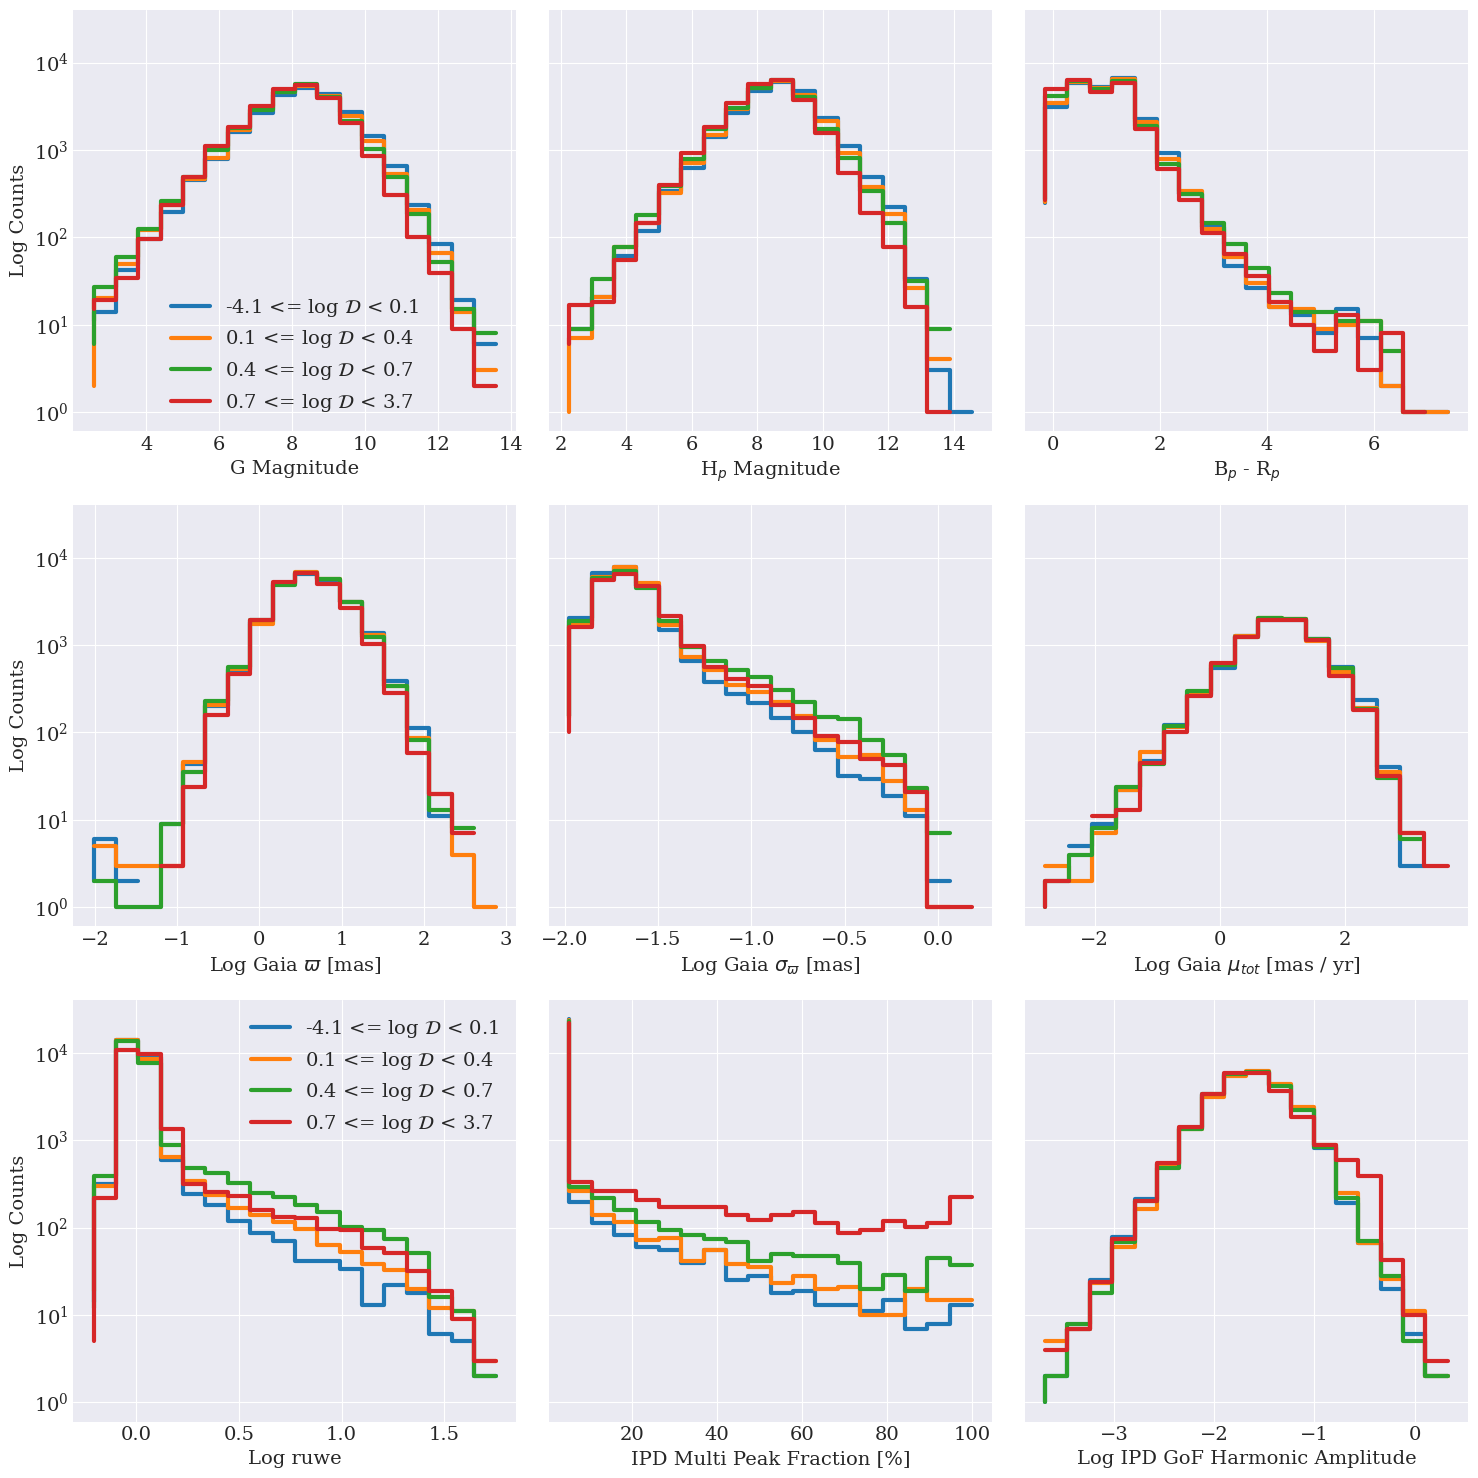

In [76]:
set_styles()
print(extra_gaia_data_params)
log_error_norm_distances = np.log10(error_norm_distances)
dnames = ['phot_g_mean_mag', 'hp_mag', 'bp_rp', 'parallax', 'parallax_error', 'mu_tot', 'ruwe', 'ipd_frac_multi_peak', 'ipd_gof_harmonic_amplitude']
names = ['G Magnitude', r'H$_p$ Magnitude', r'B$_p$ - R$_p$', r'Log Gaia $\varpi$ [mas]', r'Log Gaia $\sigma_{\varpi}$ [mas]', 'Log Gaia $\mu_{tot}$ [mas / yr]', 'Log ruwe', 'IPD Multi Peak Fraction [%]', 'Log IPD GoF Harmonic Amplitude']
do_log = [False, False, False, True, True, True, True, False, True]#, True, True, True, False, False]
num_params = len(extra_gaia_data_params)

dim = int(np.ceil(np.sqrt(num_params))) # Might change this later. For now a square is good

fig, axs = plt.subplots(dim,dim,figsize=(15,15), sharey=True, tight_layout=True)

num_D_bins = 5
D_bins = np.zeros(num_D_bins)
for i in range(num_D_bins):
    q = i * (100./(num_D_bins-1))
    D_bins[i] = np.percentile(log_error_norm_distances, q)

#D_bins = np.linspace(np.min(log_error_norm_distances), np.max(log_error_norm_distances), 4)

for i, ax in enumerate(axs.flatten()):
    if i < num_params:
        #print(extra_gdata[:,i])
        if dnames[i] == 'mu_tot':
            xdata = np.log10(np.sqrt(extra_gdata[:,1]**2 + extra_gdata[:,i]**2))
        if dnames[i] == 'hp_mag':
            xdata = extra_hdata[:,0]
        elif do_log[i]:
            xdata = np.log10(extra_gdata[:,i])
        else:
            xdata = extra_gdata[:,i]
        xlabel = names[i]
        #print(xdata)
        xbins = np.linspace(np.nanmin(xdata), np.nanmax(xdata), 20)
        bin_width = xbins[1] - xbins[0]

        distributions = compute_conditional_probability(xdata, log_error_norm_distances, xbins, D_bins, normalize=False)
        distributions[distributions < 1e-10] = np.nan
        for j in range(distributions.shape[0]):
            label = f'{D_bins[j]:.1f} <= ' + r'log $\mathcal{D}$' + f' < {D_bins[j+1]:.1f}'
                   
            if (i % dim) == 0:
                ax.step(xbins[:-1] + bin_width, distributions[j], label=label, lw=3)
            else:
                ax.step(xbins[:-1] + bin_width, distributions[j], lw=3)

        ax.set_xlabel(xlabel)
        if (i % dim) == 0:
            ax.set_ylabel('Log Counts')
            if i in [0,6]:
                ax.legend()
        ax.set_yscale('log')
        print(f'plot{i}')
    #print(len(np.where(~np.isnan(xdata))[0]))
#plt.suptitle('Gaia Conditional Probabilities of X given D in the indicated range')
plt.savefig(fpath+'gaia_conditionals.png', bbox_inches='tight', transparent=False)
plt.show()

In [ ]:
plt.hist(extra_gdata[:,1])

In [ ]:
print(np.max(extra_gdata[:,1]))

In [ ]:
plt.hist(extra_gdata[:,1])

In [ ]:
print(np.max(extra_gdata[:,1]))